# Exploratory vs Explanatory (maps to lecture section “Exploratory vs Explanatory”)


In [ ]:
# Exploratory visualization is used to understand the data, find patterns, and discover insights without a specific hypothesis in mind. It's like a brainstorming session with your data. Explanatory visualization, on the other hand, is about communicating a specific finding or story to an audience in a clear and concise manner. It's about presenting conclusions rather than exploring.

# In this assignment, we are primarily producing exploratory visualizations. We are examining the dataset to understand its characteristics, identify relationships, and uncover interesting aspects of the video game sales data.

In [ ]:
# Anscombe's quartet is mentioned to demonstrate how identical summary statistics can hide vastly different data distributions, reinforcing that visualizations are essential for true data understanding.

#Matplotlib and Seaborn (maps to lecture section “Matplotlib and
Seaborn”)


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Imported necessary libraries: `pandas` for data manipulation, `matplotlib.pyplot` for plotting, and `seaborn` for enhanced visualizations.

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gregorut/videogamesales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'videogamesales' dataset.
Path to dataset files: /kaggle/input/videogamesales


In [5]:
df = pd.read_csv(path + "/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [7]:
print('Shape (rows, cols):', df.shape)

Shape (rows, cols): (16598, 11)


In [8]:
print('\nColumn dtypes:')

# .dtypes shows the data type of each column.
#   'object' = text (string)
#   'int64'  = whole number
#   'float64' = decimal number
print(df.dtypes)


Column dtypes:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [9]:
print('\nMissing values per column:')
# df.isna() returns a True/False table (True wherever the cell is missing).
# .sum() then counts the Trues per column (because True = 1, False = 0).
print(df.isna().sum())


Missing values per column:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


## Plain Matplotlib

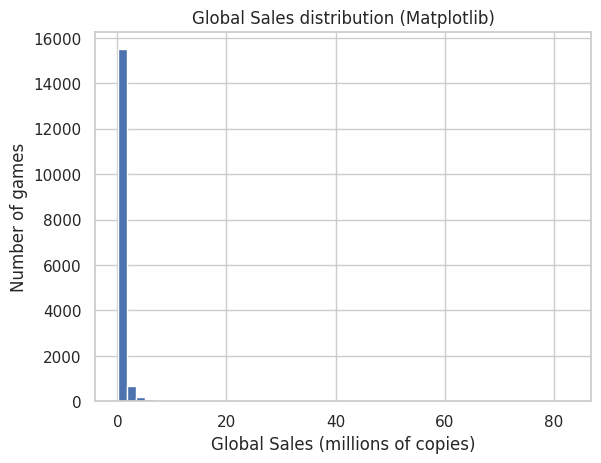

In [11]:
plt.hist(df["Global_Sales"], bins=50)

# .title()  → puts a title on top of the chart.
plt.title('Global Sales distribution (Matplotlib)')

# .xlabel() → labels the X axis (horizontal).
plt.xlabel('Global Sales (millions of copies)')

# .ylabel() → labels the Y axis (vertical).
plt.ylabel('Number of games')

# plt.show() displays the chart. Without it, sometimes nothing appears.
plt.show()

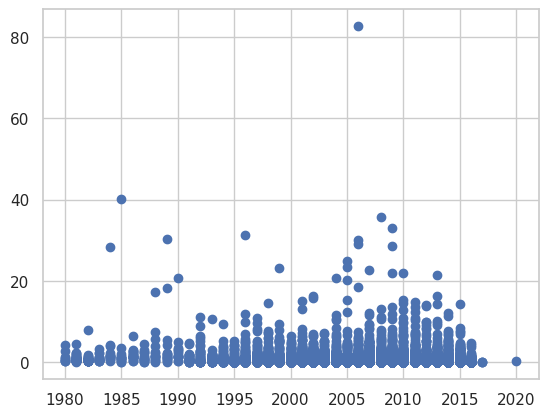

In [13]:
plt.scatter(df["Year"], df["Global_Sales"])

This scatter plot visualizes the relationship between the year of release and global sales. Each point represents a video game, with its x-coordinate being the release year and its y-coordinate being its global sales. This helps in observing any trends or patterns in sales over the years.

##Seaborn (preferred for statistical work)

In [14]:
sns.set_theme(style='whitegrid')

<Axes: xlabel='NA_Sales', ylabel='Count'>

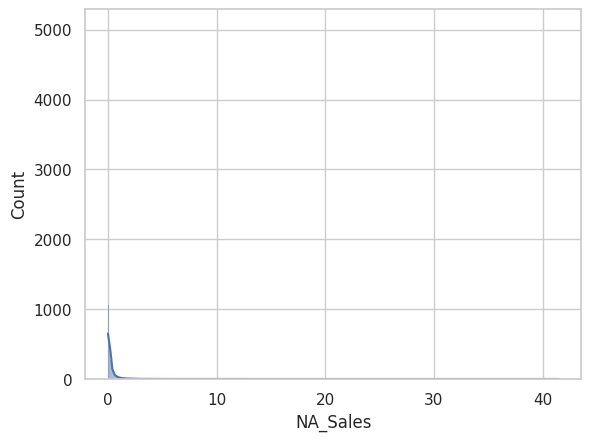

In [18]:
sns.histplot(df, x="NA_Sales", kde=True)

This `histplot` visualizes the distribution of 'NA_Sales', showing the frequency of games within different sales ranges in North America. The `kde=True` argument adds a Kernel Density Estimate to illustrate the probability density function.

<Axes: xlabel='Genre', ylabel='EU_Sales'>

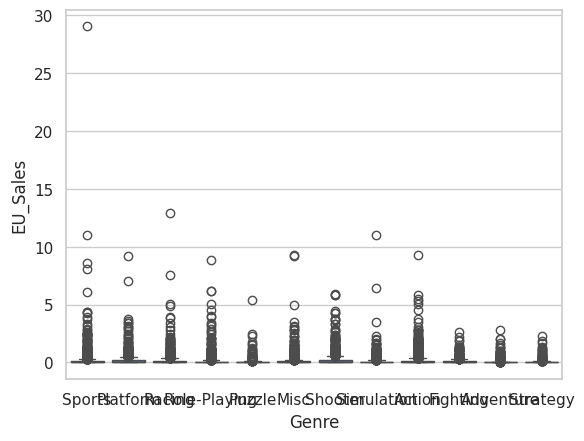

In [20]:
sns.boxplot(df, x="Genre", y="EU_Sales")

This box plot visualizes the distribution of 'EU_Sales' across different game 'Genre' categories. It shows the median, quartiles, and potential outliers for sales in Europe for each genre.

<Axes: xlabel='NA_Sales', ylabel='EU_Sales'>

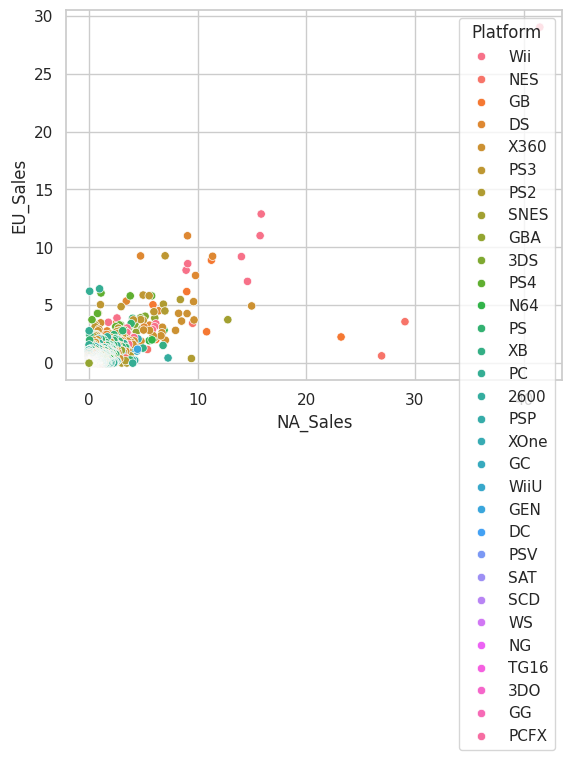

In [21]:
sns.scatterplot(df, x="NA_Sales", y="EU_Sales", hue="Platform")

This scatter plot visualizes the relationship between sales in North America (`NA_Sales`) and Europe (`EU_Sales`), with different platforms (`Platform`) highlighted by color. This helps in understanding how sales in these two regions correlate and if certain platforms perform differently across them.

<Axes: >

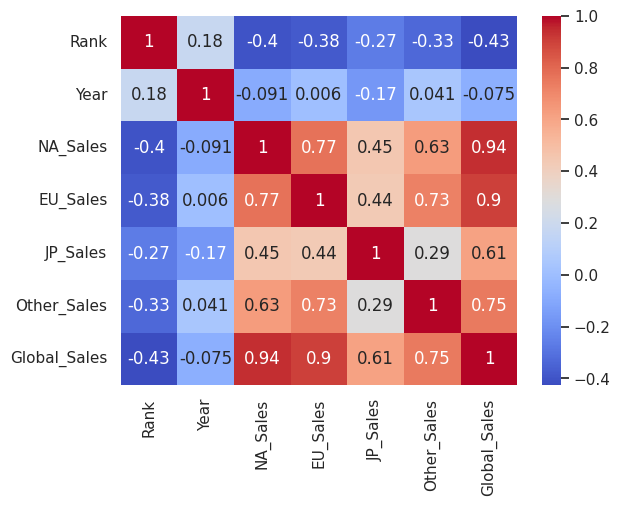

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

This heatmap visualizes the correlation matrix of the numerical columns in the DataFrame. The `annot=True` argument displays the correlation values on the heatmap, and `cmap="coolwarm"` sets the color scheme, where warmer colors indicate positive correlations and cooler colors indicate negative correlations. This helps in quickly identifying relationships between different sales metrics and other numerical features.

In [15]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


##OO Matplotlib for control

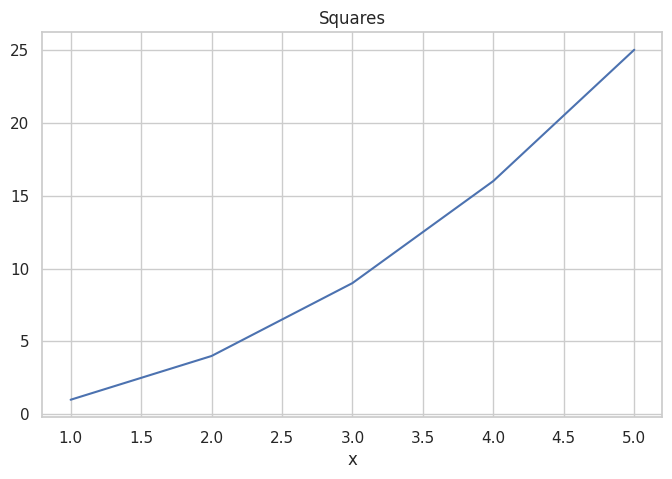

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]
ax.plot(x, y)
ax.set_xlabel("x")
ax.set_title("Squares")
fig.savefig("out.png", dpi=150)

This code snippet uses the object-oriented interface of Matplotlib to create a simple line plot. It initializes a figure and an axes object, plots a list of `x` and `y` values (representing squares), sets the x-axis label and a title, and then saves the figure as `out.png` with a specified DPI.

#Five Rules for Honest Charts (maps to lecture section “Five Rules for Honest Charts”)


Let's audit the Seaborn heatmap `sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")` against the five rules for honest charts:

1.  **Are axes labelled with units?**
    *   **N/A**: The heatmap displays correlation coefficients, which are unitless, and the axes are labeled with column names.
2.  **If it’s a bar chart, does the y-axis start at zero?**
    *   **N/A**: This is a heatmap, not a bar chart.
3.  **Is it the right chart type for the question?**
    *   **Yes**: A heatmap is an effective chart type for visualizing a correlation matrix, clearly showing the strength and direction of relationships between multiple numerical variables.
4.  **Is there any chartjunk (3D, shadows, decorative colors)?**
    *   **No**: The `coolwarm` colormap is standard and functional for diverging data, and `annot=True` adds informative values, not decorative elements.
5.  **Does it carry one clear message — or many competing ones?**
    *   **Yes**: The heatmap clearly conveys the pairwise correlations between all numerical variables, allowing for quick identification of strong or weak relationships.

## Log scale moment

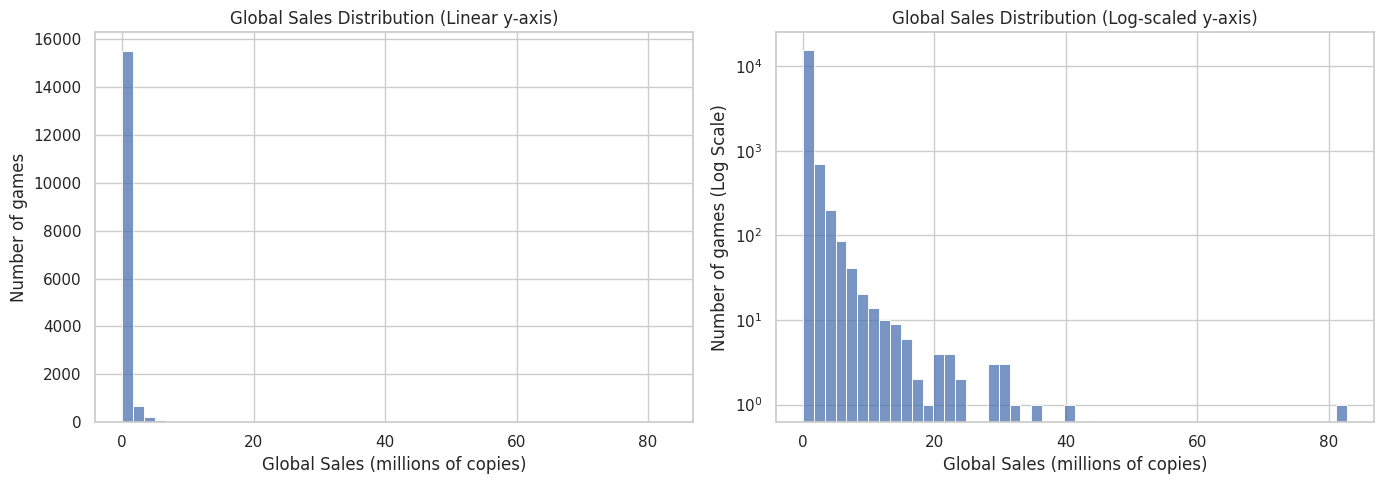

The log scale reveals the detailed distribution of games with lower sales, which were compressed at the bottom of the linear y-axis, providing clearer insights into their frequency.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear y-axis
sns.histplot(df['Global_Sales'], bins=50, ax=axes[0])
axes[0].set_title('Global Sales Distribution (Linear y-axis)')
axes[0].set_xlabel('Global Sales (millions of copies)')
axes[0].set_ylabel('Number of games')

# Log-scaled y-axis
sns.histplot(df['Global_Sales'], bins=50, ax=axes[1])
axes[1].set_title('Global Sales Distribution (Log-scaled y-axis)')
axes[1].set_xlabel('Global Sales (millions of copies)')
axes[1].set_ylabel('Number of games (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Explanation
print('The log scale reveals the detailed distribution of games with lower sales, which were compressed at the bottom of the linear y-axis, providing clearer insights into their frequency.')

# Exploratory vs Explanatory (maps to lecture section “Exploratory vs Explanatory”)


In [ ]:
# Exploratory visualization is used to understand the data, find patterns, and discover insights without a specific hypothesis in mind. It's like a brainstorming session with your data. Explanatory visualization, on the other hand, is about communicating a specific finding or story to an audience in a clear and concise manner. It's about presenting conclusions rather than exploring.

# In this assignment, we are primarily producing exploratory visualizations. We are examining the dataset to understand its characteristics, identify relationships, and uncover interesting aspects of the video game sales data.

In [ ]:
# Anscombe's quartet is mentioned to demonstrate how identical summary statistics can hide vastly different data distributions, reinforcing that visualizations are essential for true data understanding.

#Matplotlib and Seaborn (maps to lecture section “Matplotlib and
Seaborn”)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Imported necessary libraries: `pandas` for data manipulation, `matplotlib.pyplot` for plotting, and `seaborn` for enhanced visualizations.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gregorut/videogamesales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'videogamesales' dataset.
Path to dataset files: /kaggle/input/videogamesales


In [ ]:
df = pd.read_csv(path + "/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
print('Shape (rows, cols):', df.shape)

Shape (rows, cols): (16598, 11)


In [ ]:
print('\nColumn dtypes:')

# .dtypes shows the data type of each column.
#   'object' = text (string)
#   'int64'  = whole number
#   'float64' = decimal number
print(df.dtypes)


Column dtypes:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [ ]:
print('\nMissing values per column:')
# df.isna() returns a True/False table (True wherever the cell is missing).
# .sum() then counts the Trues per column (because True = 1, False = 0).
print(df.isna().sum())


Missing values per column:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


## Plain Matplotlib

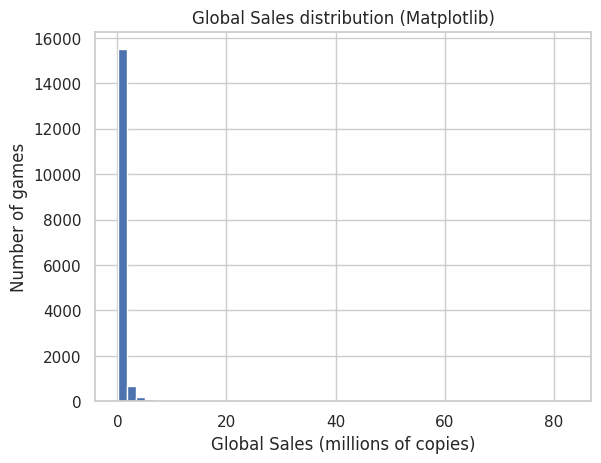

In [ ]:
plt.hist(df["Global_Sales"], bins=50)

# .title()  → puts a title on top of the chart.
plt.title('Global Sales distribution (Matplotlib)')

# .xlabel() → labels the X axis (horizontal).
plt.xlabel('Global Sales (millions of copies)')

# .ylabel() → labels the Y axis (vertical).
plt.ylabel('Number of games')

# plt.show() displays the chart. Without it, sometimes nothing appears.
plt.show()

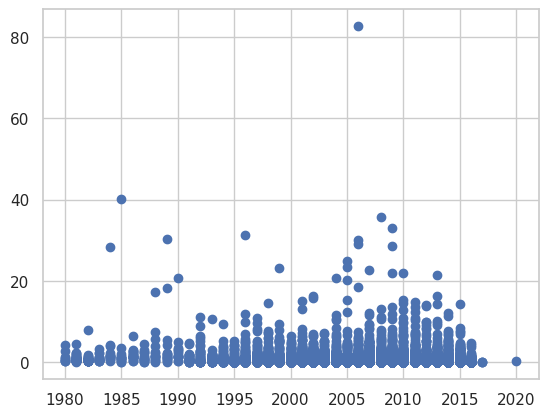

In [ ]:
plt.scatter(df["Year"], df["Global_Sales"])

This scatter plot visualizes the relationship between the year of release and global sales. Each point represents a video game, with its x-coordinate being the release year and its y-coordinate being its global sales. This helps in observing any trends or patterns in sales over the years.

##Seaborn (preferred for statistical work)

In [ ]:
sns.set_theme(style='whitegrid')

<Axes: xlabel='NA_Sales', ylabel='Count'>

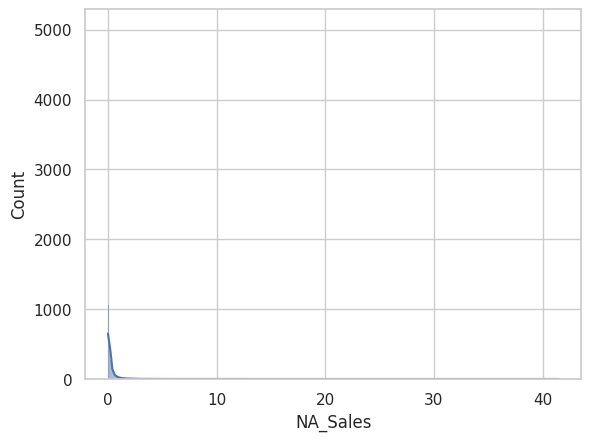

In [ ]:
sns.histplot(df, x="NA_Sales", kde=True)

This `histplot` visualizes the distribution of 'NA_Sales', showing the frequency of games within different sales ranges in North America. The `kde=True` argument adds a Kernel Density Estimate to illustrate the probability density function.

<Axes: xlabel='Genre', ylabel='EU_Sales'>

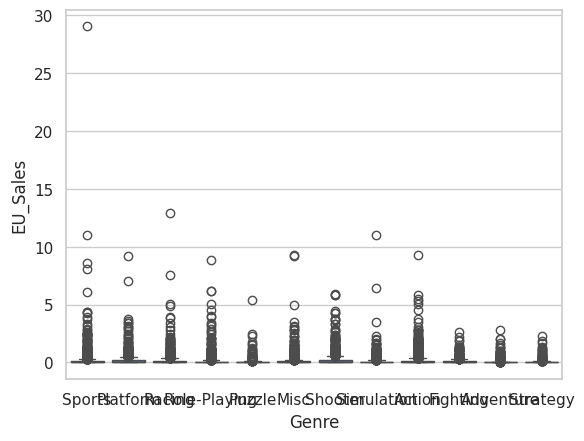

In [ ]:
sns.boxplot(df, x="Genre", y="EU_Sales")

This box plot visualizes the distribution of 'EU_Sales' across different game 'Genre' categories. It shows the median, quartiles, and potential outliers for sales in Europe for each genre.

<Axes: xlabel='NA_Sales', ylabel='EU_Sales'>

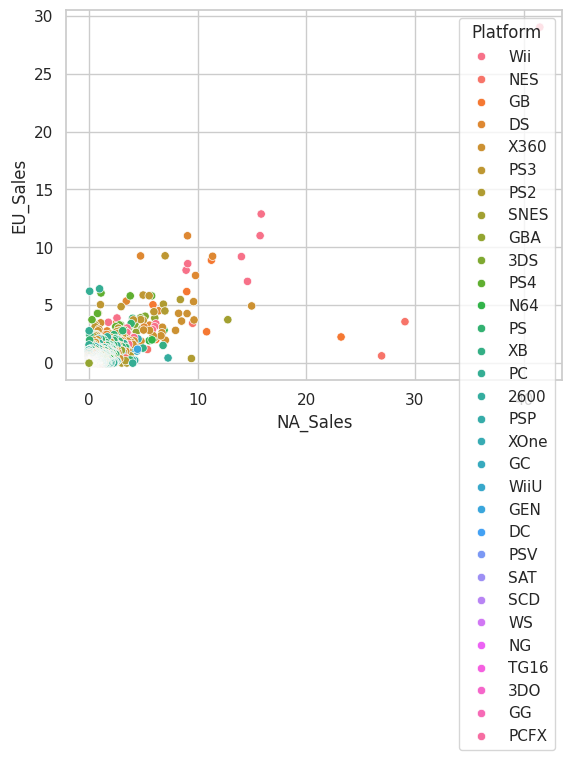

In [ ]:
sns.scatterplot(df, x="NA_Sales", y="EU_Sales", hue="Platform")

This scatter plot visualizes the relationship between sales in North America (`NA_Sales`) and Europe (`EU_Sales`), with different platforms (`Platform`) highlighted by color. This helps in understanding how sales in these two regions correlate and if certain platforms perform differently across them.

<Axes: >

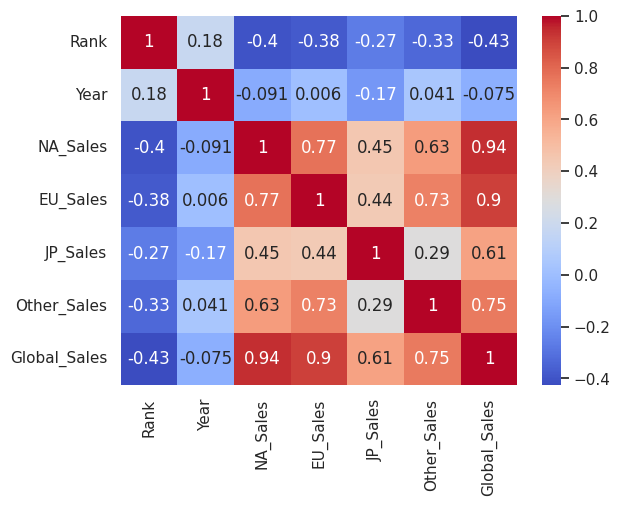

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

This heatmap visualizes the correlation matrix of the numerical columns in the DataFrame. The `annot=True` argument displays the correlation values on the heatmap, and `cmap="coolwarm"` sets the color scheme, where warmer colors indicate positive correlations and cooler colors indicate negative correlations. This helps in quickly identifying relationships between different sales metrics and other numerical features.

In [ ]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


##OO Matplotlib for control

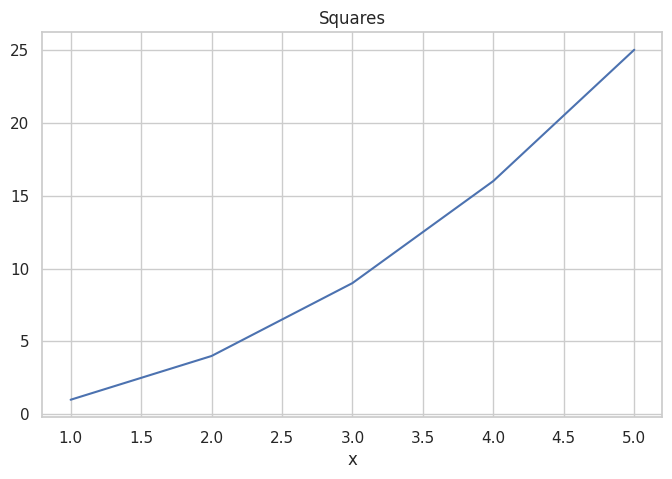

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]
ax.plot(x, y)
ax.set_xlabel("x")
ax.set_title("Squares")
fig.savefig("out.png", dpi=150)

This code snippet uses the object-oriented interface of Matplotlib to create a simple line plot. It initializes a figure and an axes object, plots a list of `x` and `y` values (representing squares), sets the x-axis label and a title, and then saves the figure as `out.png` with a specified DPI.

#Five Rules for Honest Charts (maps to lecture section “Five Rules for Honest Charts”)


Let's audit the Seaborn heatmap `sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")` against the five rules for honest charts:

1.  **Are axes labelled with units?**
    *   **N/A**: The heatmap displays correlation coefficients, which are unitless, and the axes are labeled with column names.
2.  **If it’s a bar chart, does the y-axis start at zero?**
    *   **N/A**: This is a heatmap, not a bar chart.
3.  **Is it the right chart type for the question?**
    *   **Yes**: A heatmap is an effective chart type for visualizing a correlation matrix, clearly showing the strength and direction of relationships between multiple numerical variables.
4.  **Is there any chartjunk (3D, shadows, decorative colors)?**
    *   **No**: The `coolwarm` colormap is standard and functional for diverging data, and `annot=True` adds informative values, not decorative elements.
5.  **Does it carry one clear message — or many competing ones?**
    *   **Yes**: The heatmap clearly conveys the pairwise correlations between all numerical variables, allowing for quick identification of strong or weak relationships.

## Log scale moment

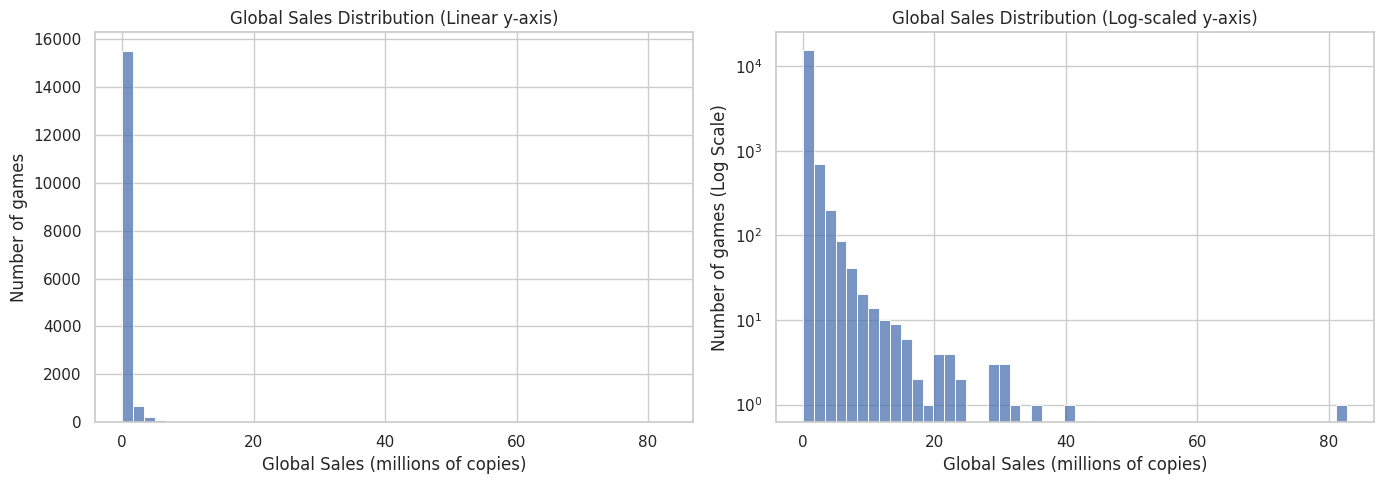

The log scale reveals the detailed distribution of games with lower sales, which were compressed at the bottom of the linear y-axis, providing clearer insights into their frequency.


In [ ]:
```
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear y-axis
sns.histplot(df['Global_Sales'], bins=50, ax=axes[0])
axes[0].set_title('Global Sales Distribution (Linear y-axis)')
axes[0].set_xlabel('Global Sales (millions of copies)')
axes[0].set_ylabel('Number of games')

# Log-scaled y-axis
sns.histplot(df['Global_Sales'], bins=50, ax=axes[1])
axes[1].set_title('Global Sales Distribution (Log-scaled y-axis)')
axes[1].set_xlabel('Global Sales (millions of copies)')
axes[1].set_ylabel('Number of games (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Explanation
print('The log scale reveals the detailed distribution of games with lower sales, which were compressed at the bottom of the linear y-axis, providing clearer insights into their frequency.')

# Exploratory vs Explanatory (maps to lecture section “Exploratory vs Explanatory”)


In [ ]:
# Exploratory visualization is used to understand the data, find patterns, and discover insights without a specific hypothesis in mind. It's like a brainstorming session with your data. Explanatory visualization, on the other hand, is about communicating a specific finding or story to an audience in a clear and concise manner. It's about presenting conclusions rather than exploring.

# In this assignment, we are primarily producing exploratory visualizations. We are examining the dataset to understand its characteristics, identify relationships, and uncover interesting aspects of the video game sales data.

In [ ]:
# Anscombe's quartet is mentioned to demonstrate how identical summary statistics can hide vastly different data distributions, reinforcing that visualizations are essential for true data understanding.

#Matplotlib and Seaborn (maps to lecture section “Matplotlib and
Seaborn”)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Imported necessary libraries: `pandas` for data manipulation, `matplotlib.pyplot` for plotting, and `seaborn` for enhanced visualizations.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gregorut/videogamesales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'videogamesales' dataset.
Path to dataset files: /kaggle/input/videogamesales


In [ ]:
df = pd.read_csv(path + "/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
print('Shape (rows, cols):', df.shape)

Shape (rows, cols): (16598, 11)


In [ ]:
print('\nColumn dtypes:')

# .dtypes shows the data type of each column.
#   'object' = text (string)
#   'int64'  = whole number
#   'float64' = decimal number
print(df.dtypes)


Column dtypes:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [ ]:
print('\nMissing values per column:')
# df.isna() returns a True/False table (True wherever the cell is missing).
# .sum() then counts the Trues per column (because True = 1, False = 0).
print(df.isna().sum())


Missing values per column:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


## Plain Matplotlib

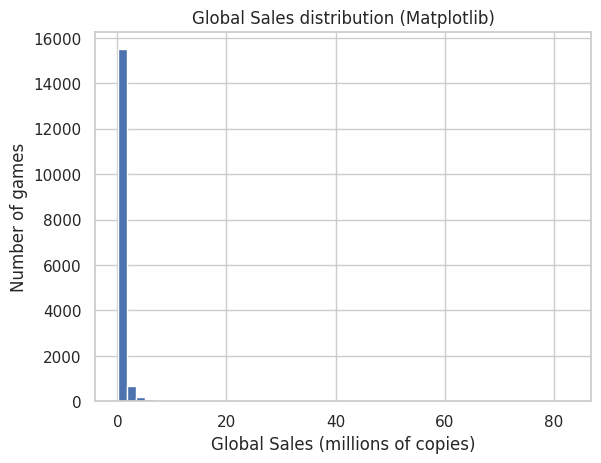

In [ ]:
plt.hist(df["Global_Sales"], bins=50)

# .title()  → puts a title on top of the chart.
plt.title('Global Sales distribution (Matplotlib)')

# .xlabel() → labels the X axis (horizontal).
plt.xlabel('Global Sales (millions of copies)')

# .ylabel() → labels the Y axis (vertical).
plt.ylabel('Number of games')

# plt.show() displays the chart. Without it, sometimes nothing appears.
plt.show()

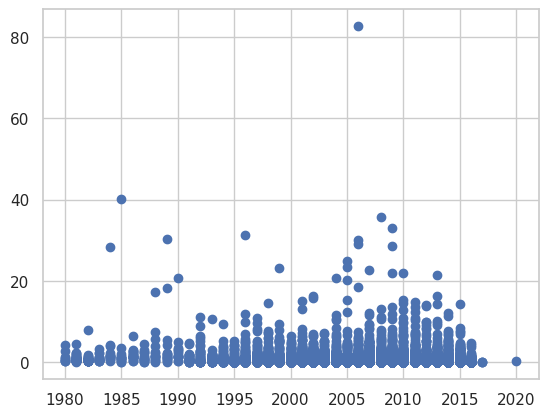

In [ ]:
plt.scatter(df["Year"], df["Global_Sales"])

This scatter plot visualizes the relationship between the year of release and global sales. Each point represents a video game, with its x-coordinate being the release year and its y-coordinate being its global sales. This helps in observing any trends or patterns in sales over the years.

##Seaborn (preferred for statistical work)

In [ ]:
sns.set_theme(style='whitegrid')

<Axes: xlabel='NA_Sales', ylabel='Count'>

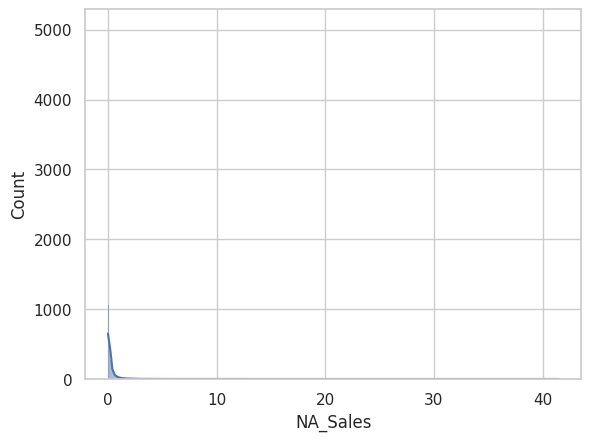

In [ ]:
sns.histplot(df, x="NA_Sales", kde=True)

This `histplot` visualizes the distribution of 'NA_Sales', showing the frequency of games within different sales ranges in North America. The `kde=True` argument adds a Kernel Density Estimate to illustrate the probability density function.

<Axes: xlabel='Genre', ylabel='EU_Sales'>

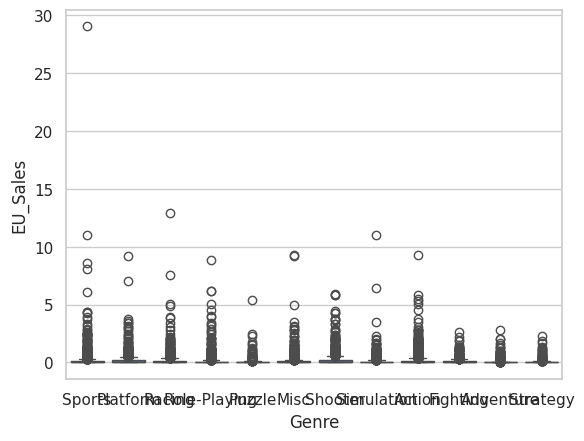

In [ ]:
sns.boxplot(df, x="Genre", y="EU_Sales")

This box plot visualizes the distribution of 'EU_Sales' across different game 'Genre' categories. It shows the median, quartiles, and potential outliers for sales in Europe for each genre.

<Axes: xlabel='NA_Sales', ylabel='EU_Sales'>

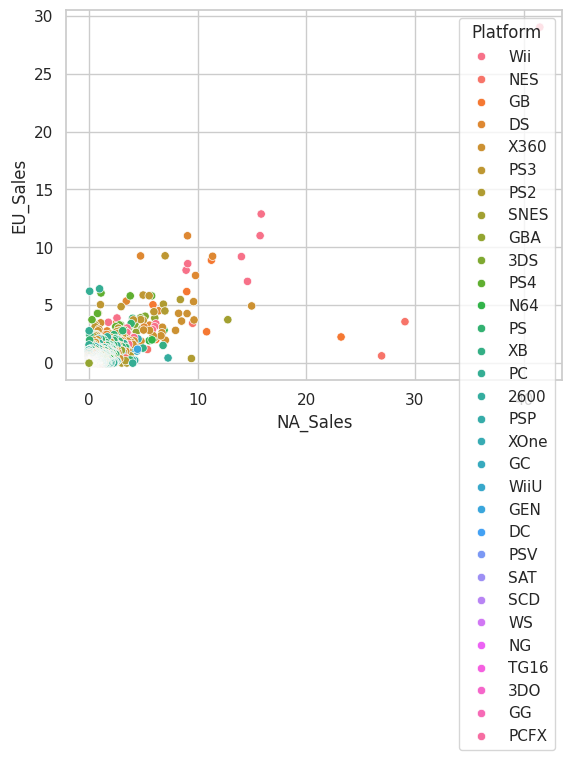

In [ ]:
sns.scatterplot(df, x="NA_Sales", y="EU_Sales", hue="Platform")

This scatter plot visualizes the relationship between sales in North America (`NA_Sales`) and Europe (`EU_Sales`), with different platforms (`Platform`) highlighted by color. This helps in understanding how sales in these two regions correlate and if certain platforms perform differently across them.

<Axes: >

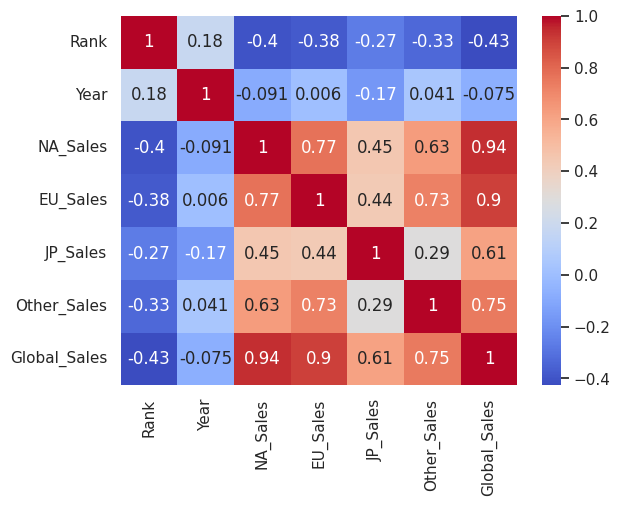

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

This heatmap visualizes the correlation matrix of the numerical columns in the DataFrame. The `annot=True` argument displays the correlation values on the heatmap, and `cmap="coolwarm"` sets the color scheme, where warmer colors indicate positive correlations and cooler colors indicate negative correlations. This helps in quickly identifying relationships between different sales metrics and other numerical features.

In [ ]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


##OO Matplotlib for control

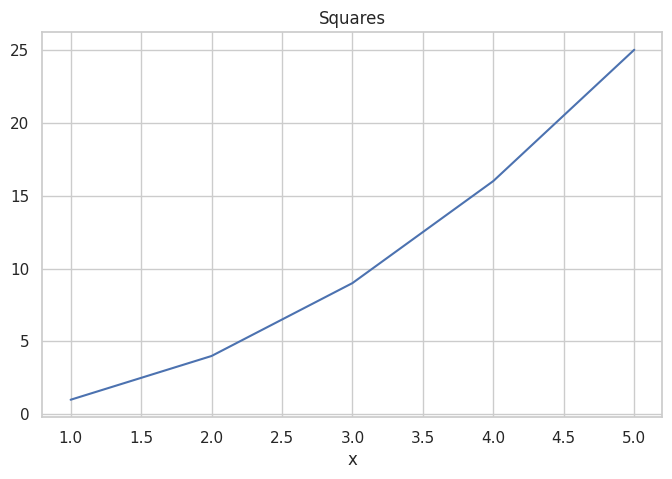

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]
ax.plot(x, y)
ax.set_xlabel("x")
ax.set_title("Squares")
fig.savefig("out.png", dpi=150)

This code snippet uses the object-oriented interface of Matplotlib to create a simple line plot. It initializes a figure and an axes object, plots a list of `x` and `y` values (representing squares), sets the x-axis label and a title, and then saves the figure as `out.png` with a specified DPI.

#Five Rules for Honest Charts (maps to lecture section “Five Rules for Honest Charts”)


Let's audit the Seaborn heatmap `sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")` against the five rules for honest charts:

1.  **Are axes labelled with units?**
    *   **N/A**: The heatmap displays correlation coefficients, which are unitless, and the axes are labeled with column names.
2.  **If it’s a bar chart, does the y-axis start at zero?**
    *   **N/A**: This is a heatmap, not a bar chart.
3.  **Is it the right chart type for the question?**
    *   **Yes**: A heatmap is an effective chart type for visualizing a correlation matrix, clearly showing the strength and direction of relationships between multiple numerical variables.
4.  **Is there any chartjunk (3D, shadows, decorative colors)?**
    *   **No**: The `coolwarm` colormap is standard and functional for diverging data, and `annot=True` adds informative values, not decorative elements.
5.  **Does it carry one clear message — or many competing ones?**
    *   **Yes**: The heatmap clearly conveys the pairwise correlations between all numerical variables, allowing for quick identification of strong or weak relationships.

## Log scale moment

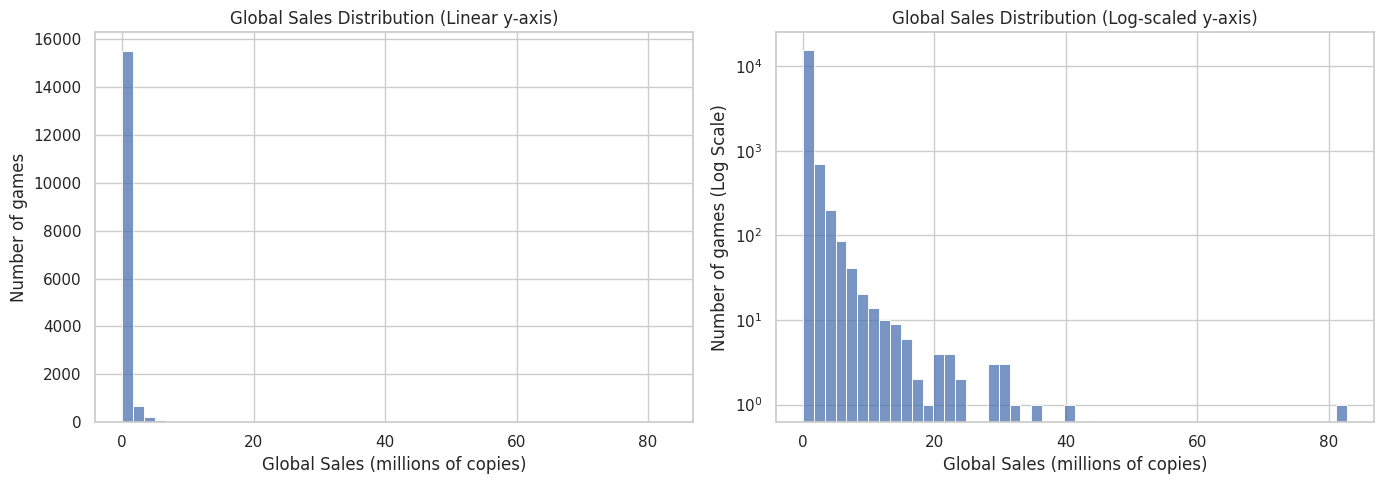

The log scale reveals the detailed distribution of games with lower sales, which were compressed at the bottom of the linear y-axis, providing clearer insights into their frequency.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear y-axis
sns.histplot(df['Global_Sales'], bins=50, ax=axes[0])
axes[0].set_title('Global Sales Distribution (Linear y-axis)')
axes[0].set_xlabel('Global Sales (millions of copies)')
axes[0].set_ylabel('Number of games')

# Log-scaled y-axis
sns.histplot(df['Global_Sales'], bins=50, ax=axes[1])
axes[1].set_title('Global Sales Distribution (Log-scaled y-axis)')
axes[1].set_xlabel('Global Sales (millions of copies)')
axes[1].set_ylabel('Number of games (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Explanation
print('The log scale reveals the detailed distribution of games with lower sales, which were compressed at the bottom of the linear y-axis, providing clearer insights into their frequency.')

# Exploratory vs Explanatory (maps to lecture section “Exploratory vs Explanatory”)


In [ ]:
# Exploratory visualization is used to understand the data, find patterns, and discover insights without a specific hypothesis in mind. It's like a brainstorming session with your data. Explanatory visualization, on the other hand, is about communicating a specific finding or story to an audience in a clear and concise manner. It's about presenting conclusions rather than exploring.

# In this assignment, we are primarily producing exploratory visualizations. We are examining the dataset to understand its characteristics, identify relationships, and uncover interesting aspects of the video game sales data.

In [ ]:
# Anscombe's quartet is mentioned to demonstrate how identical summary statistics can hide vastly different data distributions, reinforcing that visualizations are essential for true data understanding.

#Matplotlib and Seaborn (maps to lecture section “Matplotlib and
Seaborn”)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Imported necessary libraries: `pandas` for data manipulation, `matplotlib.pyplot` for plotting, and `seaborn` for enhanced visualizations.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gregorut/videogamesales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'videogamesales' dataset.
Path to dataset files: /kaggle/input/videogamesales


In [ ]:
df = pd.read_csv(path + "/vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
print('Shape (rows, cols):', df.shape)

Shape (rows, cols): (16598, 11)


In [ ]:
print('\nColumn dtypes:')

# .dtypes shows the data type of each column.
#   'object' = text (string)
#   'int64'  = whole number
#   'float64' = decimal number
print(df.dtypes)


Column dtypes:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


In [ ]:
print('\nMissing values per column:')
# df.isna() returns a True/False table (True wherever the cell is missing).
# .sum() then counts the Trues per column (because True = 1, False = 0).
print(df.isna().sum())


Missing values per column:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


## Plain Matplotlib

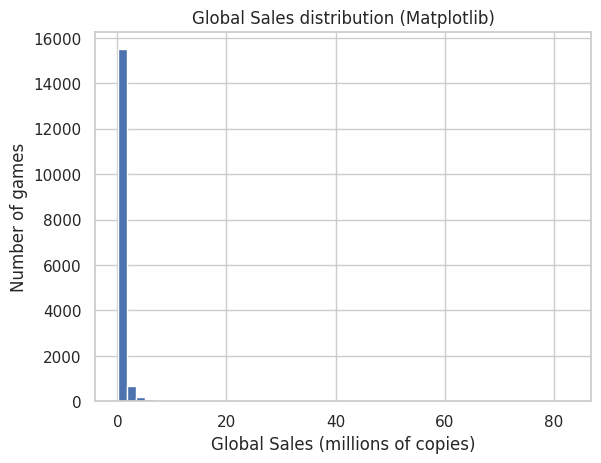

In [ ]:
plt.hist(df["Global_Sales"], bins=50)

# .title()  → puts a title on top of the chart.
plt.title('Global Sales distribution (Matplotlib)')

# .xlabel() → labels the X axis (horizontal).
plt.xlabel('Global Sales (millions of copies)')

# .ylabel() → labels the Y axis (vertical).
plt.ylabel('Number of games')

# plt.show() displays the chart. Without it, sometimes nothing appears.
plt.show()

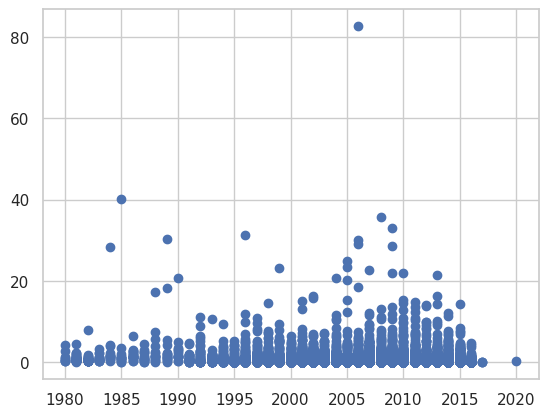

In [ ]:
plt.scatter(df["Year"], df["Global_Sales"])

This scatter plot visualizes the relationship between the year of release and global sales. Each point represents a video game, with its x-coordinate being the release year and its y-coordinate being its global sales. This helps in observing any trends or patterns in sales over the years.

##Seaborn (preferred for statistical work)

In [ ]:
sns.set_theme(style='whitegrid')

<Axes: xlabel='NA_Sales', ylabel='Count'>

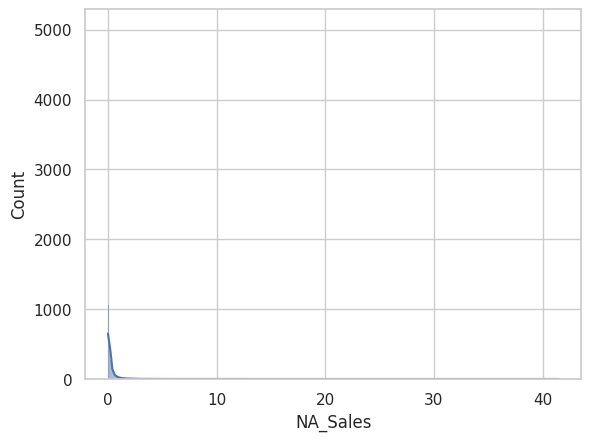

In [ ]:
sns.histplot(df, x="NA_Sales", kde=True)

This `histplot` visualizes the distribution of 'NA_Sales', showing the frequency of games within different sales ranges in North America. The `kde=True` argument adds a Kernel Density Estimate to illustrate the probability density function.

<Axes: xlabel='Genre', ylabel='EU_Sales'>

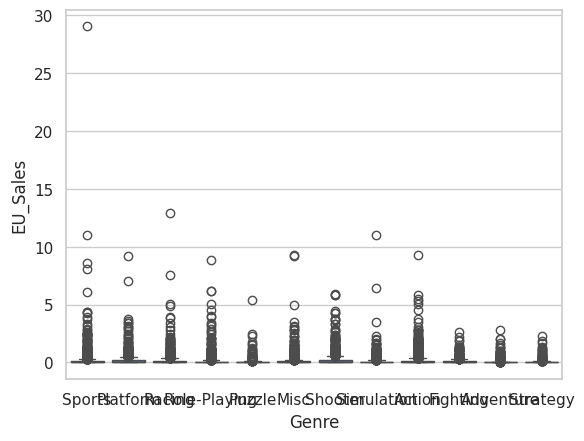

In [ ]:
sns.boxplot(df, x="Genre", y="EU_Sales")

This box plot visualizes the distribution of 'EU_Sales' across different game 'Genre' categories. It shows the median, quartiles, and potential outliers for sales in Europe for each genre.

<Axes: xlabel='NA_Sales', ylabel='EU_Sales'>

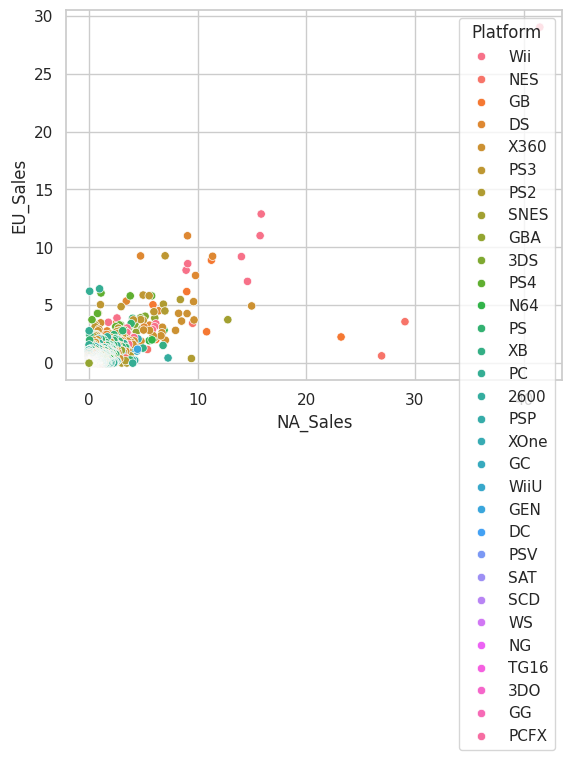

In [ ]:
sns.scatterplot(df, x="NA_Sales", y="EU_Sales", hue="Platform")

This scatter plot visualizes the relationship between sales in North America (`NA_Sales`) and Europe (`EU_Sales`), with different platforms (`Platform`) highlighted by color. This helps in understanding how sales in these two regions correlate and if certain platforms perform differently across them.

<Axes: >

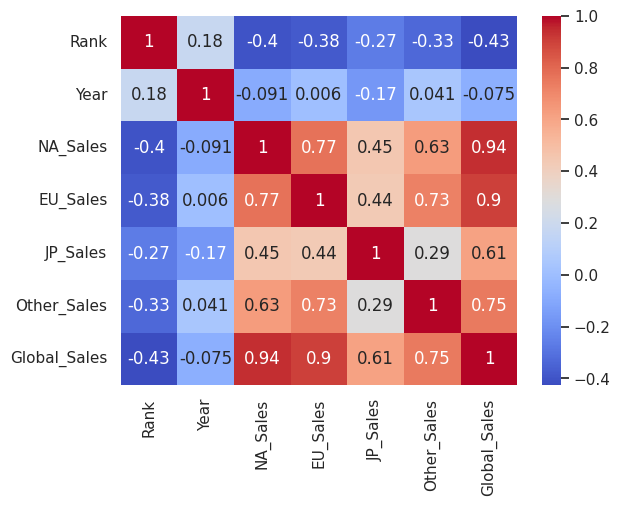

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

This heatmap visualizes the correlation matrix of the numerical columns in the DataFrame. The `annot=True` argument displays the correlation values on the heatmap, and `cmap="coolwarm"` sets the color scheme, where warmer colors indicate positive correlations and cooler colors indicate negative correlations. This helps in quickly identifying relationships between different sales metrics and other numerical features.

In [ ]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


##OO Matplotlib for control

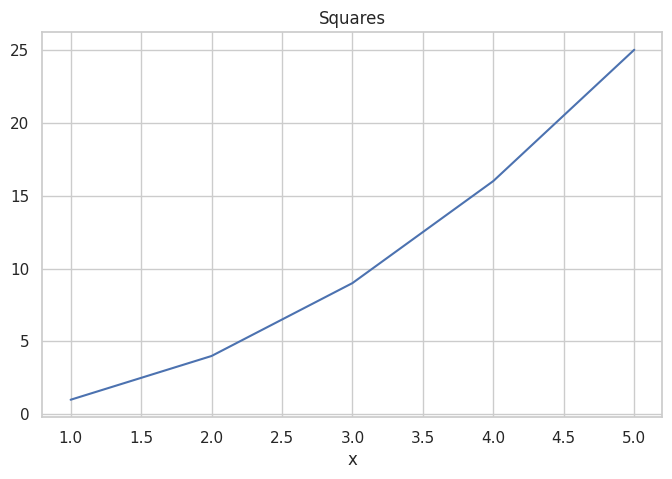

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]
ax.plot(x, y)
ax.set_xlabel("x")
ax.set_title("Squares")
fig.savefig("out.png", dpi=150)

This code snippet uses the object-oriented interface of Matplotlib to create a simple line plot. It initializes a figure and an axes object, plots a list of `x` and `y` values (representing squares), sets the x-axis label and a title, and then saves the figure as `out.png` with a specified DPI.

#Five Rules for Honest Charts (maps to lecture section “Five Rules for Honest Charts”)


Let's audit the Seaborn heatmap `sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")` against the five rules for honest charts:

1.  **Are axes labelled with units?**
    *   **N/A**: The heatmap displays correlation coefficients, which are unitless, and the axes are labeled with column names.
2.  **If it’s a bar chart, does the y-axis start at zero?**
    *   **N/A**: This is a heatmap, not a bar chart.
3.  **Is it the right chart type for the question?**
    *   **Yes**: A heatmap is an effective chart type for visualizing a correlation matrix, clearly showing the strength and direction of relationships between multiple numerical variables.
4.  **Is there any chartjunk (3D, shadows, decorative colors)?**
    *   **No**: The `coolwarm` colormap is standard and functional for diverging data, and `annot=True` adds informative values, not decorative elements.
5.  **Does it carry one clear message — or many competing ones?**
    *   **Yes**: The heatmap clearly conveys the pairwise correlations between all numerical variables, allowing for quick identification of strong or weak relationships.

## Log scale moment

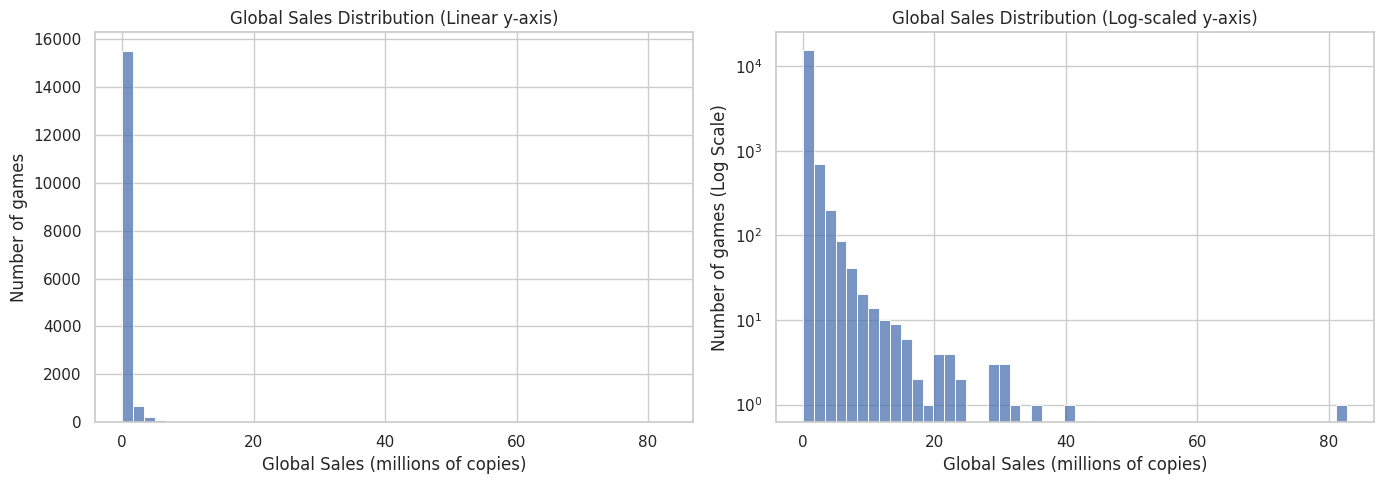

The log scale reveals the detailed distribution of games with lower sales, which were compressed at the bottom of the linear y-axis, providing clearer insights into their frequency.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear y-axis
sns.histplot(df['Global_Sales'], bins=50, ax=axes[0])
axes[0].set_title('Global Sales Distribution (Linear y-axis)')
axes[0].set_xlabel('Global Sales (millions of copies)')
axes[0].set_ylabel('Number of games')

# Log-scaled y-axis
sns.histplot(df['Global_Sales'], bins=50, ax=axes[1])
axes[1].set_title('Global Sales Distribution (Log-scaled y-axis)')
axes[1].set_xlabel('Global Sales (millions of copies)')
axes[1].set_ylabel('Number of games (Log Scale)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Explanation
print('The log scale reveals the detailed distribution of games with lower sales, which were compressed at the bottom of the linear y-axis, providing clearer insights into their frequency.')